# Analyse du Marché Immobilier Français

Ce notebook présente une analyse des données foncières issues de la plateforme publique [data.gouv.fr](https://www.data.gouv.fr/fr/datasets/demandes-de-valeurs-foncieres/).  
L’objectif est de fournir une vision claire et exploitable du marché immobilier afin d’identifier les zones les plus attractives pour un investisseur.

Les étapes de ce travail comprennent :
1. Le chargement et la préparation des données foncières.
2. L’analyse descriptive des prix au mètre carré et de leur évolution.
3. La mise en évidence des zones dynamiques et des types de biens attractifs.
4. La formulation de recommandations destinées à un investisseur souhaitant optimiser sa stratégie d’achat.


## Persona – Investisseur cible

**Nom :** Marc Dubois  
**Âge :** 42 ans  
**Profil :** Cadre supérieur résidant en région parisienne, souhaitant investir dans l’immobilier locatif pour préparer sa retraite.  

### Objectifs
- Identifier les **arrondissments les plus rentables** pour un investissement locatif.  
- Trouver les **types de biens les plus attractifs** selon les arrondissements.  
- Éviter les **zones à risque** (prix instables, faible rendement, insécurité).  
- Repérer les **zones en croissance**, présentant un fort potentiel de valorisation à moyen terme.  

### Attentes vis-à-vis du notebook
- Des **visualisations claires et lisibles**, sans jargon technique.  
- Des **indicateurs simples** (prix au m², évolution sur 3 ans, volume de ventes, etc.).  
- Des **recommandations concrètes** pour orienter ses décisions d’investissement.  

> Ce persona servira de fil conducteur pour interpréter les résultats et formuler des recommandations adaptées.


In [20]:
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv("paris_appart_filtre.csv")
df.info()
df.describe()
df.head(100)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81362 entries, 0 to 81361
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date mutation        81362 non-null  object 
 1   Nature mutation      81362 non-null  object 
 2   Valeur fonciere      81362 non-null  float64
 3   Code postal          81362 non-null  float64
 4   Commune              81362 non-null  object 
 5   Type local           81362 non-null  object 
 6   Surface reelle bati  81362 non-null  float64
 7   prix m2              81362 non-null  float64
 8   annee                81362 non-null  int64  
 9   mois                 81362 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 6.2+ MB


,Date mutation,Nature mutation,Valeur fonciere,Code postal,Commune,Type local,Surface reelle bati,prix m2,annee,mois
0,2022-01-06,Vente,605000.0,75003.0,PARIS 03,Appartement,42.0,14404.761905,2022,1
1,2022-01-05,Vente,716250.0,75009.0,PARIS 09,Appartement,69.0,10380.434783,2022,1
2,2022-01-05,Vente,320000.0,75010.0,PARIS 10,Appartement,33.0,9696.969697,2022,1
3,2022-01-07,Vente,320000.0,75020.0,PARIS 20,Appartement,29.0,11034.482759,2022,1
4,2022-01-06,Vente,220000.0,75020.0,PARIS 20,Appartement,36.0,6111.111111,2022,1
...,...,...,...,...,...,...,...,...,...,...
95,2022-01-11,Vente,165000.0,75018.0,PARIS 18,Appartement,21.0,7857.142857,2022,1
96,2022-01-11,Vente,128000.0,75020.0,PARIS 20,Appartement,15.0,8533.333333,2022,1
97,2022-01-06,Vente,232000.0,75009.0,PARIS 09,Appartement,16.0,14500.000000,2022,1
98,2022-01-10,Vente,463000.0,75019.0,PARIS 19,Appartement,53.0,8735.849057,2022,1


Ce fichier provient de la base publique DVF disponible sur data.gouv.fr.
Il a été filtré et nettoyé à l’aide de Pandas afin de ne conserver que les transactions pertinentes pour notre analyse (biens à usage d’habitation, zones géographiques ciblées).
Il contient les informations nécessaires pour calculer le prix moyen au m², suivre l’évolution du marché sur 3 ans et identifier les zones les plus attractives pour un investisseur immobilier.


In [21]:
##df.describe()
df[df['prix m2']>60000000]

,Date mutation,Nature mutation,Valeur fonciere,Code postal,Commune,Type local,Surface reelle bati,prix m2,annee,mois


In [22]:
#Prix moyen au m2 par commune
prix_m2_ville = df.groupby(["Commune"])["prix m2"].mean().reset_index().round(0)

prix_m2_ville["prix m2"] = prix_m2_ville["prix m2"].round(0)

prix_m2_ville = prix_m2_ville.sort_values(by="prix m2", ascending=False)
prix_m2_ville.head(100)



,Commune,prix m2
5,PARIS 06,13727.0
6,PARIS 07,13523.0
3,PARIS 04,12752.0
0,PARIS 01,12562.0
7,PARIS 08,12395.0
4,PARIS 05,12219.0
2,PARIS 03,12111.0
1,PARIS 02,11708.0
15,PARIS 16,11523.0
8,PARIS 09,11354.0


In [23]:
#Evolution du prix sur 3 ans

evol = df.groupby(["Commune", "annee"])["prix m2"].mean().reset_index().round(0)

pivot = evol.pivot(index="Commune", columns="annee", values="prix m2")

annees_dispo = sorted(df["annee"].unique())
if len(annees_dispo) >= 3:
    annee_recente = annees_dispo[-1]
    annee_avant = annees_dispo[-3]
    evolution = (
        (pivot[annee_recente] - pivot[annee_avant]) / pivot[annee_avant] * 100
    ).round(2)
    
    pivot["evolution sur 3 ans (en %)"] = evolution
    
pivot.columns.name = None #Suite a un beug d'affichage


pivot = pivot.reset_index()
pivot.head(100)


,Commune,2022,2023,2024,evolution sur 3 ans (en %)
0,PARIS 01,12697.0,12598.0,12314.0,-3.02
1,PARIS 02,12021.0,11725.0,11222.0,-6.65
2,PARIS 03,12349.0,12141.0,11760.0,-4.77
3,PARIS 04,13005.0,12857.0,12326.0,-5.22
4,PARIS 05,12765.0,12136.0,11643.0,-8.79
5,PARIS 06,13976.0,13694.0,13446.0,-3.79
6,PARIS 07,13865.0,13481.0,13126.0,-5.33
7,PARIS 08,12657.0,12506.0,11975.0,-5.39
8,PARIS 09,11752.0,11376.0,10777.0,-8.30
9,PARIS 10,10617.0,10128.0,9528.0,-10.26


In [24]:
#Nombre de transactions par commune

transactions = (
    df.groupby("Commune")["Valeur fonciere"]
    .count()
    .reset_index()
    .rename(columns={"Valeur fonciere": "nb_transactions"})
)
transactions.head(20)


,Commune,nb_transactions
0,PARIS 01,776
1,PARIS 02,1137
2,PARIS 03,1765
3,PARIS 04,1305
4,PARIS 05,2334
5,PARIS 06,1727
6,PARIS 07,1994
7,PARIS 08,1588
8,PARIS 09,3096
9,PARIS 10,4308


In [25]:
'''#Trouvons la vente la plus commune dans chaque commune

vente_commune = (
    df.groupby(["Commune", "Type local"])
    .size()
    .reset_index(name="nb_ventes")
)

vente_commune  = vente_commune.loc[
    vente_commune.groupby("Commune")["nb_ventes"].idxmax()
].reset_index(drop=True)

vente_commune.head()

#Il ya  des appartements, des maisons et des locaux industriels. Trouvons la part des ventes de chaque types dans chaque commune. Ces trois ne sont pas frocement les seuls types, il peut en evoir dautre
type_local = df["Type local"].unique()
type_local = df["Type local"].value_counts(normalize=True).reset_index()
type_local.columns = ["Type local", "Proportion"]
type_local["Proportion"] = (type_local["Proportion"] * 100).round(2)
type_local.head()'''

#Mettons ces pourcentages pour chqque commune.
vente_commune = (
    df.groupby(["Commune", "Type local"])
    .size()
    .reset_index(name="nb_ventes")
)
vente_commune["proportion"] = (
    vente_commune.groupby("Commune")["nb_ventes"].transform(lambda x: (x / x.sum()) * 100)
).round(2)
#vente_commune.head()


vente_commune = vente_commune.pivot(
    index="Commune",
    columns="Type local",
    values="proportion"
).reset_index()

vente_commune.columns = [
    col if col == "Commune" else f"{col} (en %)"
    for col in vente_commune.columns
]

vente_commune.head(100)

,Commune,Appartement (en %)
0,PARIS 01,100.0
1,PARIS 02,100.0
2,PARIS 03,100.0
3,PARIS 04,100.0
4,PARIS 05,100.0
5,PARIS 06,100.0
6,PARIS 07,100.0
7,PARIS 08,100.0
8,PARIS 09,100.0
9,PARIS 10,100.0


In [26]:
#Avec tout ca, mettons tout ensemble
final = prix_m2_ville.merge(pivot, on="Commune").merge(transactions, on="Commune").merge(vente_commune, on="Commune")
final = final.sort_values(by="prix m2", ascending=False)
final.head(100)

,Commune,prix m2,2022,2023,2024,evolution sur 3 ans (en %),nb_transactions,Appartement (en %)
0,PARIS 06,13727.0,13976.0,13694.0,13446.0,-3.79,1727,100.0
1,PARIS 07,13523.0,13865.0,13481.0,13126.0,-5.33,1994,100.0
2,PARIS 04,12752.0,13005.0,12857.0,12326.0,-5.22,1305,100.0
3,PARIS 01,12562.0,12697.0,12598.0,12314.0,-3.02,776,100.0
4,PARIS 08,12395.0,12657.0,12506.0,11975.0,-5.39,1588,100.0
5,PARIS 05,12219.0,12765.0,12136.0,11643.0,-8.79,2334,100.0
6,PARIS 03,12111.0,12349.0,12141.0,11760.0,-4.77,1765,100.0
7,PARIS 02,11708.0,12021.0,11725.0,11222.0,-6.65,1137,100.0
8,PARIS 16,11523.0,11889.0,11509.0,11027.0,-7.25,6588,100.0
9,PARIS 09,11354.0,11752.0,11376.0,10777.0,-8.30,3096,100.0


In [27]:
final_sort=final.sort_values(by="Commune", ascending=True)
final_sort["c_ar"]=final_sort["Commune"].str.extract(r'(\d+)$')[0].astype(int)
final_sort.head(20)

,Commune,prix m2,2022,2023,2024,evolution sur 3 ans (en %),nb_transactions,Appartement (en %),c_ar
3,PARIS 01,12562.0,12697.0,12598.0,12314.0,-3.02,776,100.0,1
7,PARIS 02,11708.0,12021.0,11725.0,11222.0,-6.65,1137,100.0,2
6,PARIS 03,12111.0,12349.0,12141.0,11760.0,-4.77,1765,100.0,3
2,PARIS 04,12752.0,13005.0,12857.0,12326.0,-5.22,1305,100.0,4
5,PARIS 05,12219.0,12765.0,12136.0,11643.0,-8.79,2334,100.0,5
0,PARIS 06,13727.0,13976.0,13694.0,13446.0,-3.79,1727,100.0,6
1,PARIS 07,13523.0,13865.0,13481.0,13126.0,-5.33,1994,100.0,7
4,PARIS 08,12395.0,12657.0,12506.0,11975.0,-5.39,1588,100.0,8
9,PARIS 09,11354.0,11752.0,11376.0,10777.0,-8.30,3096,100.0,9
13,PARIS 10,10158.0,10617.0,10128.0,9528.0,-10.26,4308,100.0,10


## Interprétation des résultats

Les analyses précédentes permettent d’identifier plusieurs tendances significatives sur le marché immobilier :
- Le prix moyen au mètre carré varie fortement selon les régions et la taille des communes.
- L’évolution sur trois ans révèle des zones en forte croissance, souvent situées dans des villes de taille moyenne bénéficiant d’une bonne attractivité économique.
- Le nombre de transactions confirme l’activité du marché dans certaines zones urbaines et périurbaines.




In [28]:
# https://www.data.gouv.fr/datasets/arrondissements-1/
import geopandas as gpd
# Charger les arrondissements
carte_prix_m2 = gpd.read_file("arrondissements.geojson")
carte_prix_m2.sort_values(by='c_ar', inplace=True, ignore_index=True)

carte_prix_evo = gpd.read_file("arrondissements.geojson")
carte_nb_transaction= gpd.read_file("arrondissements.geojson")
carte_prix_evo.sort_values(by='c_ar', inplace=True, ignore_index=True)
carte_nb_transaction.sort_values(by='c_ar', inplace=True, ignore_index=True)



#ajout données
"""
tempo = pd.DataFrame()
tempo["prix m2"]=final["prix m2"]
tempo["Commune"]=final["Commune"]
tempo.sort_values(inplace=True, ignore_index=True, by="Commune")
carte_prix_m2["prix m2"]=tempo["prix m2"]
"""
carte_prix_m2=pd.merge(carte_prix_m2, final_sort[['c_ar', 'prix m2']], on='c_ar', how='left')
carte_prix_evo=pd.merge(carte_prix_m2, final_sort[['c_ar', 'evolution sur 3 ans (en %)']], on='c_ar', how='left')
carte_nb_transaction=pd.merge(carte_prix_m2, final_sort[['c_ar', 'nb_transactions']], on='c_ar', how='left')

carte_prix_m2.head(20)

DataSourceError: arrondissements.geojson: No such file or directory

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact, interactive
import numpy as np

#%matplotlib widget

#calcul attractivité
carte_attract = gpd.read_file("arrondissements.geojson")

#croissance normalisée:
final_sort["evo_norm"]=(final_sort["evolution sur 3 ans (en %)"]-final_sort["evolution sur 3 ans (en %)"].min())/(final_sort["evolution sur 3 ans (en %)"].max()-final_sort["evolution sur 3 ans (en %)"].min())
#prix normalise
final_sort["prix_norm"] = (final_sort["prix m2"] - final_sort["prix m2"].min()) / (final_sort["prix m2"].max() - final_sort["prix m2"].min())
final_sort["prix_norm_inv"] = 1 - final_sort["prix_norm"]
#transaction normalisée
final_sort["transac_norm"]=(final_sort["nb_transactions"]-final_sort["nb_transactions"].min())/(final_sort["nb_transactions"].max()-final_sort["nb_transactions"].min())
#final.head(20)

carte_attract["attract"] = (final_sort["evo_norm"] + final_sort["prix_norm_inv"] + final_sort["transac_norm"])

carte_attract = carte_attract.sort_values(by="c_ar")

def attract(coef_Evolution_prix=1.0, coef_Prix_m2=1.0, coef_Nb_transaction=1.0):
    plt.clf()
    carte_attract["attract"] = (coef_Evolution_prix * final_sort["evo_norm"] + coef_Prix_m2 * final_sort["prix_norm_inv"] + coef_Nb_transaction * final_sort["transac_norm"])
    plt.show()

#interact(attract, coef_Evolution_prix=(0.0, 3.0, 0.2), coef_Prix_m2=(0.0, 3.0, 0.2), coef_Nb_transaction=(0.0, 3.0, 0.2));
interact(attract, coef_Evolution_prix=(0.0, 3.0, 0.2), coef_Prix_m2=(0.0, 3.0, 0.2), coef_Nb_transaction=(0.0, 3.0, 0.2));
#slider pour gerer les coefficients

ModuleNotFoundError: No module named 'ipywidgets'

Text(0.5, 1.0, "Score d'attractivite par arrondissement")

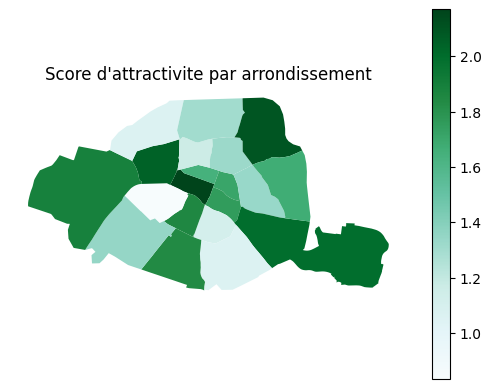

In [ ]:
#executer pour actualiser avec les données du dessus
carte_attract.plot(column="attract", cmap="BuGn", legend=True, )
plt.axis('off')
plt.title("Score d'attractivite par arrondissement")

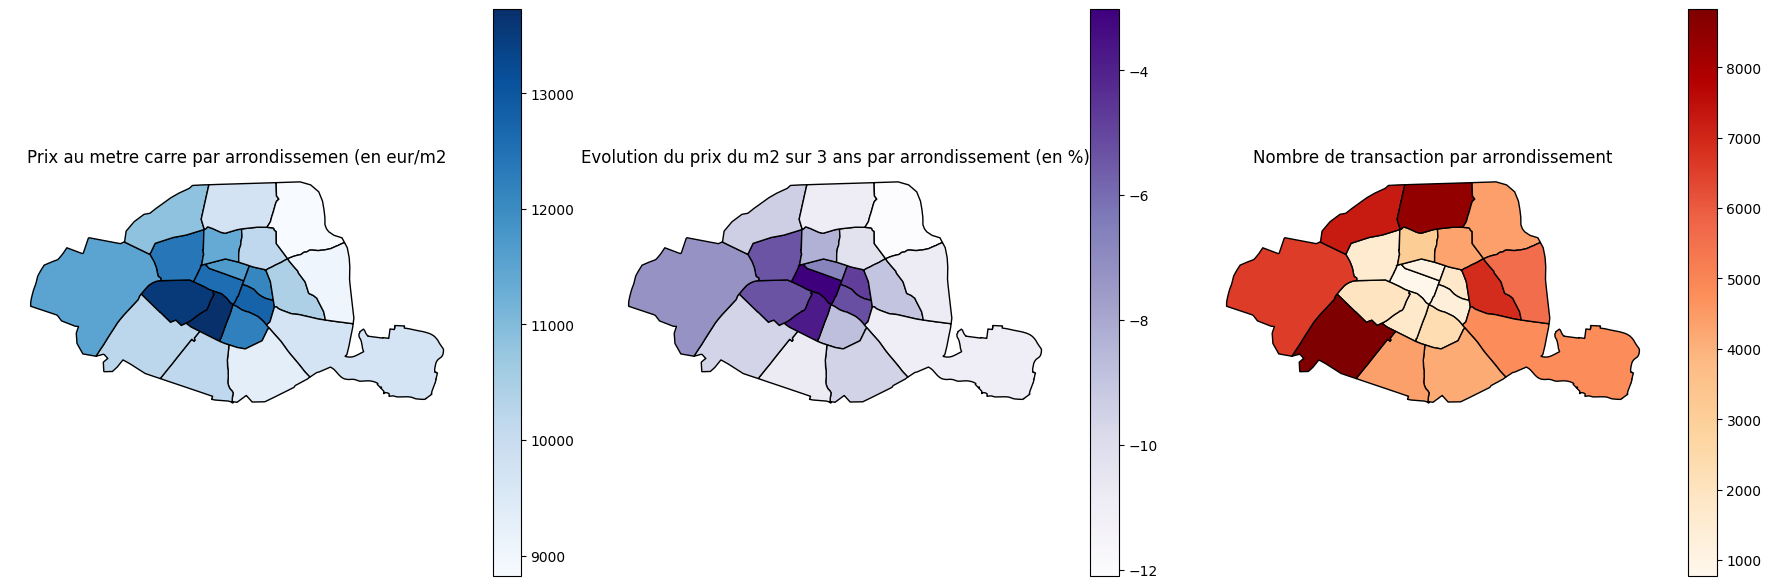

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 ligne, 3 colonnes

# Plot sur chaque axe
carte_prix_m2.plot(ax=axes[0],column='prix m2', cmap='Blues', edgecolor='black', legend=True)
axes[0].set_title('Prix au metre carre par arrondissemen (en eur/m2')
axes[0].set_axis_off()

carte_prix_evo.plot(ax=axes[1],column='evolution sur 3 ans (en %)', cmap='Purples', edgecolor='black', legend=True)
axes[1].set_title('Evolution du prix du m2 sur 3 ans par arrondissement (en %)')
axes[1].set_axis_off()

carte_nb_transaction.plot(ax=axes[2],column='nb_transactions', cmap='OrRd', edgecolor='black', legend=True)
axes[2].set_title('Nombre de transaction par arrondissement')
axes[2].set_axis_off()

plt.tight_layout()
plt.show()


## Recommandations pour l’investissement immobilier

À partir des tendances observées, plusieurs pistes d’investissement peuvent être dégagées.

### Zones attractives
Les régions présentant une **hausse continue des prix sur trois ans** et un **volume élevé de transactions** peuvent être considérées comme attractives pour l’investissement locatif.  
Elles offrent un **potentiel de plus-value à moyen terme** ainsi qu’une **demande locative soutenue**.

### Types de biens
- **Appartements et studios** : particulièrement rentables dans les centres urbains où la demande est forte (étudiants, jeunes actifs).  

### Zones à risque
Les zones caractérisées par une **stagnation ou une baisse des prix**, associées à un **faible volume de ventes**, sont à éviter à court terme.  
Ces marchés présentent un **risque de vacance locative plus élevé** et un **potentiel de revente limité**.


### Exemple concret d’un bon investissement à Paris

À partir des données visualisées dans les widgets, un bon exemple d’investissement peut être identifié dans **le 11ᵉ arrondissement de Paris**.

- **Localisation :** Paris 11ᵉ arrondissement  
- **Prix moyen au m² :** environ **9 500 €**  
- **Type de bien conseillé :** studio ou petit deux-pièces  
- **Évolution du prix sur 3 ans :** **-6 à -8 %** selon les quartiers  
- **Volume de transactions :** élevé, marché fluide  
- **Taux de vacance locative :** très faible  
- **Accès transports :** lignes 2, 3, 5 et 9 du métro, nombreux commerces et espaces de coworking  

#### Pourquoi cet investissement est attractif :
1. **Demande locative forte** : le 11ᵉ attire de nombreux jeunes actifs, freelances et étudiants, garantissant une occupation quasi continue.  
2. **Potentiel de plus-value modéré mais stable** : les prix restent soutenus, avec une évolution régulière sans surchauffe.  
3. **Quartier dynamique et central** : excellente desserte en transports, proximité du Marais et de Bastille, nombreux services de proximité.  
4. **Bonne rentabilité relative pour Paris** : les petites surfaces offrent une **rentabilité brute estimée entre 4 % et 4,5 %**, supérieure à la moyenne parisienne.  

En résumé, un **studio de 25 à 30 m²** dans le 11ᵉ arrondissement constitue un investissement équilibré entre **sécurité patrimoniale et rendement locatif**.


## Conclusion

Cette étude met en évidence l’hétérogénéité du marché immobilier français et l’importance d’une approche fondée sur les données pour orienter un investissement.  
Les résultats suggèrent que les villes moyennes et les zones périurbaines dynamiques constituent aujourd’hui un compromis intéressant entre rentabilité et risque.

Les visualisations et les outils interactifs proposés permettent d’explorer différentes zones et types de biens afin d’adapter la stratégie d’achat selon les priorités de l’investisseur.
